Environment Setup & Live Data Acquisition

In [30]:
import os
import pandas as pd

BASE_DIR = os.getcwd()
RAW_DATA_DIR = os.path.join(BASE_DIR, "data")
CLEAN_DATA_DIR = os.path.join(BASE_DIR, "data", "cleaned")
os.makedirs(CLEAN_DATA_DIR, exist_ok=True)

DATA_PATH = os.path.join(RAW_DATA_DIR, "Crime_Data_from_2020_to_Present.csv")
CLEAN_PATH = os.path.join(CLEAN_DATA_DIR, "Crime_Data_from_2020_to_Present_Cleaned.csv")

df = pd.read_csv(DATA_PATH)

In [31]:
df.info()
df.head()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004991 entries, 0 to 1004990
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1004991 non-null  int64  
 1   Date Rptd       1004991 non-null  object 
 2   DATE OCC        1004991 non-null  object 
 3   TIME OCC        1004991 non-null  int64  
 4   AREA            1004991 non-null  int64  
 5   AREA NAME       1004991 non-null  object 
 6   Rpt Dist No     1004991 non-null  int64  
 7   Part 1-2        1004991 non-null  int64  
 8   Crm Cd          1004991 non-null  int64  
 9   Crm Cd Desc     1004991 non-null  object 
 10  Mocodes         853372 non-null   object 
 11  Vict Age        1004991 non-null  int64  
 12  Vict Sex        860347 non-null   object 
 13  Vict Descent    860335 non-null   object 
 14  Premis Cd       1004975 non-null  float64
 15  Premis Desc     1004403 non-null  object 
 16  Weapon Used Cd  327247 non-null   fl

,DR_NO,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LAT,LON
count,1.004991e+06,1.004991e+06,1.004991e+06,1.004991e+06,1.004991e+06,1.004991e+06,1.004991e+06,1.004975e+06,327247.000000,1.004980e+06,69160.000000,2314.000000,64.00000,1.004991e+06,1.004991e+06
mean,2.202215e+08,1.339900e+03,1.069174e+01,1.115633e+03,1.400348e+00,5.001568e+02,2.891706e+01,3.056201e+02,363.955300,4.999174e+02,958.101258,984.015990,991.21875,3.399821e+01,-1.180909e+02
std,1.319718e+07,6.510613e+02,6.110255e+00,6.111605e+02,4.899691e-01,2.052731e+02,2.199272e+01,2.193021e+02,123.734528,2.050736e+02,110.354348,52.350982,27.06985,1.610713e+00,5.582386e+00
min,8.170000e+02,1.000000e+00,1.000000e+00,1.010000e+02,1.000000e+00,1.100000e+02,-4.000000e+00,1.010000e+02,101.000000,1.100000e+02,210.000000,310.000000,821.00000,0.000000e+00,-1.186676e+02
25%,2.106169e+08,9.000000e+02,5.000000e+00,5.870000e+02,1.000000e+00,3.310000e+02,0.000000e+00,1.010000e+02,311.000000,3.310000e+02,998.000000,998.000000,998.00000,3.401470e+01,-1.184305e+02
50%,2.209159e+08,1.420000e+03,1.100000e+01,1.139000e+03,1.000000e+00,4.420000e+02,3.000000e+01,2.030000e+02,400.000000,4.420000e+02,998.000000,998.000000,998.00000,3.405890e+01,-1.183225e+02
75%,2.311103e+08,1.900000e+03,1.600000e+01,1.613000e+03,2.000000e+00,6.260000e+02,4.400000e+01,5.010000e+02,400.000000,6.260000e+02,998.000000,998.000000,998.00000,3.416490e+01,-1.182739e+02
max,2.521041e+08,2.359000e+03,2.100000e+01,2.199000e+03,2.000000e+00,9.560000e+02,1.200000e+02,9.760000e+02,516.000000,9.560000e+02,999.000000,999.000000,999.00000,3.433430e+01,0.000000e+00


Rigorous Data Cleaning & Proactive Feature Engineering

In [32]:
df["LAT"] = pd.to_numeric(df["LAT"], errors="coerce")
df["LON"] = pd.to_numeric(df["LON"], errors="coerce")
df["date_occ"] = pd.to_datetime(df["DATE OCC"], errors="coerce")
df["TIME OCC"] = pd.to_numeric(df["TIME OCC"], errors="coerce")

df["occ_hour_raw"] = (df["TIME OCC"] // 100)
df["occ_minute_raw"] = (df["TIME OCC"] % 100)
df["occ_hour"] = df["occ_hour_raw"].where(df["occ_hour_raw"].between(0, 23), np.nan)
df["occ_minute"] = df["occ_minute_raw"].where(df["occ_minute_raw"].between(0, 59), np.nan)
df["occ_hour_filled"] = df["occ_hour"].fillna(0).astype(int)
df["occ_datetime"] = df["date_occ"] + pd.to_timedelta(df["occ_hour_filled"], unit="h")

df = df.dropna(subset=["date_occ", "LAT", "LON"])
df = df[(df["LAT"] != 0) & (df["LON"] != 0)]
df = df[df["LAT"].between(-90, 90) & df["LON"].between(-180, 180)]

C:\Users\aryam\AppData\Local\Temp\ipykernel_4996\575269729.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date_occ"] = pd.to_datetime(df["DATE OCC"], errors="coerce")


In [33]:
df["year"] = df["occ_datetime"].dt.year
df["month"] = df["occ_datetime"].dt.month
df["day_of_week"] = df["occ_datetime"].dt.day_name()
df["weekday_num"] = df["occ_datetime"].dt.weekday
df["is_weekend"] = df["weekday_num"].isin([5, 6]).astype(int)

def time_bucket(hour):
    if pd.isna(hour): return "Unknown"
    hour = int(hour)
    if 0 <= hour <= 5: return "Night"
    elif 6 <= hour <= 11: return "Morning"
    elif 12 <= hour <= 17: return "Afternoon"
    elif 18 <= hour <= 23: return "Evening"
    return "Unknown"

df["time_bucket"] = df["occ_hour_filled"].apply(time_bucket)

if "Part 1-2" in df.columns:
    df["crime_category"] = df["Part 1-2"].map({1: "Part1", 2: "Part2"}).fillna("Unknown")
    df["crime_category_simple"] = df["Part 1-2"].map({
        1: "Violent/Serious (Part 1)",
        2: "Property/Other (Part 2)"
    }).fillna("Unknown")

df.to_csv(CLEAN_PATH, index=False)

In [34]:
df.info()
df.head()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 1002751 entries, 0 to 1004990
Data columns (total 43 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   DR_NO                  1002751 non-null  int64         
 1   Date Rptd              1002751 non-null  object        
 2   DATE OCC               1002751 non-null  object        
 3   TIME OCC               1002751 non-null  int64         
 4   AREA                   1002751 non-null  int64         
 5   AREA NAME              1002751 non-null  object        
 6   Rpt Dist No            1002751 non-null  int64         
 7   Part 1-2               1002751 non-null  int64         
 8   Crm Cd                 1002751 non-null  int64         
 9   Crm Cd Desc            1002751 non-null  object        
 10  Mocodes                851256 non-null   object        
 11  Vict Age               1002751 non-null  int64         
 12  Vict Sex               858185 non

,DR_NO,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,...,occ_hour_raw,occ_minute_raw,occ_hour,occ_minute,occ_hour_filled,occ_datetime,year,month,weekday_num,is_weekend
count,1.002751e+06,1.002751e+06,1.002751e+06,1.002751e+06,1.002751e+06,1.002751e+06,1.002751e+06,1.002735e+06,326414.000000,1.002740e+06,...,1.002751e+06,1.002751e+06,1.002751e+06,1.002751e+06,1.002751e+06,1002751,1.002751e+06,1.002751e+06,1.002751e+06,1.002751e+06
mean,2.202494e+08,1.339982e+03,1.069231e+01,1.115687e+03,1.399672e+00,4.997775e+02,2.891327e+01,3.055341e+02,363.875682,4.995379e+02,...,1.322171e+01,1.781063e+01,1.322171e+01,1.781063e+01,1.322171e+01,2022-05-15 06:43:15.526507264,2.021882e+03,6.370519e+00,3.023610e+00,2.856442e-01
min,8.170000e+02,1.000000e+00,1.000000e+00,1.010000e+02,1.000000e+00,1.100000e+02,-4.000000e+00,1.010000e+02,101.000000,1.100000e+02,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2020-01-01 00:00:00,2.020000e+03,1.000000e+00,0.000000e+00,0.000000e+00
25%,2.106179e+08,9.000000e+02,5.000000e+00,5.870000e+02,1.000000e+00,3.310000e+02,0.000000e+00,1.010000e+02,311.000000,3.310000e+02,...,9.000000e+00,0.000000e+00,9.000000e+00,0.000000e+00,9.000000e+00,2021-04-07 15:00:00,2.021000e+03,3.000000e+00,1.000000e+00,0.000000e+00
50%,2.209175e+08,1.420000e+03,1.100000e+01,1.139000e+03,1.000000e+00,4.420000e+02,3.000000e+01,2.030000e+02,400.000000,4.420000e+02,...,1.400000e+01,1.500000e+01,1.400000e+01,1.500000e+01,1.400000e+01,2022-05-28 00:00:00,2.022000e+03,6.000000e+00,3.000000e+00,0.000000e+00
75%,2.311111e+08,1.900000e+03,1.600000e+01,1.613000e+03,2.000000e+00,6.260000e+02,4.400000e+01,5.010000e+02,400.000000,6.260000e+02,...,1.900000e+01,3.000000e+01,1.900000e+01,3.000000e+01,1.900000e+01,2023-06-23 03:00:00,2.023000e+03,9.000000e+00,5.000000e+00,1.000000e+00
max,2.521041e+08,2.359000e+03,2.100000e+01,2.199000e+03,2.000000e+00,9.560000e+02,1.200000e+02,9.760000e+02,516.000000,9.560000e+02,...,2.300000e+01,5.900000e+01,2.300000e+01,5.900000e+01,2.300000e+01,2025-05-29 08:00:00,2.025000e+03,1.200000e+01,6.000000e+00,1.000000e+00
std,1.319675e+07,6.513743e+02,6.110136e+00,6.111473e+02,4.898310e-01,2.051349e+02,2.199290e+01,2.193040e+02,123.820674,2.049347e+02,...,6.513336e+00,1.814364e+01,6.513336e+00,1.814364e+01,6.513336e+00,NaN,1.315033e+00,3.464177e+00,1.987271e+00,4.517209e-01


Data Quality Audit & Reporting

In [39]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Re-establish paths just in case the previous cell session timed out
CLEAN_DATA_DIR = os.path.join(os.getcwd(), "data", "cleaned")
QUALITY_PATH = os.path.join(CLEAN_DATA_DIR, "week1_quality_report.csv")

def generate_quality_report(df, output_path):
    # 1. Basic Completeness Audit
    quality_metrics = {
        "Total Records": len(df),
        "Missing LAT/LON": df[['LAT', 'LON']].isna().any(axis=1).sum(),
        "Invalid Coordinates (0,0)": ((df['LAT'] == 0) | (df['LON'] == 0)).sum(),
        "Missing Time Buckets": df['time_bucket'].isna().sum(),
        "Missing Crime Category": (df['crime_category_simple'] == "Unknown").sum(),
        "Average Victim Age": round(df['Vict Age'].mean(), 2),
        "Outlier Victim Age (<0 or >100)": ((df['Vict Age'] <= 0) | (df['Vict Age'] > 100)).sum()
    }

    # 2. Value Distribution for Proactive Features
    severity_dist = df['crime_category_simple'].value_counts(normalize=True).to_dict()
    time_dist = df['time_bucket'].value_counts(normalize=True).to_dict()

    # 3. Compile into a Report DataFrame
    report_df = pd.DataFrame(list(quality_metrics.items()), columns=['Metric', 'Value'])
    
    # Save to CSV
    report_df.to_csv(output_path, index=False)
    
    print("DATA QUALITY REPORT SUMMARY")
    print(report_df)
    print(f"\nDetailed report saved to: {output_path}")
    
    return report_df

# Generate the report
quality_report = generate_quality_report(df, QUALITY_PATH)

DATA QUALITY REPORT SUMMARY
                            Metric       Value
0                    Total Records  1002751.00
1                  Missing LAT/LON        0.00
2        Invalid Coordinates (0,0)        0.00
3             Missing Time Buckets        0.00
4           Missing Crime Category        0.00
5               Average Victim Age       28.91
6  Outlier Victim Age (<0 or >100)   268812.00

Detailed report saved to: c:\Users\aryam\Capstone-LAPDCrimeData\data\cleaned\week1_quality_report.csv


Exploratory Data Analysis

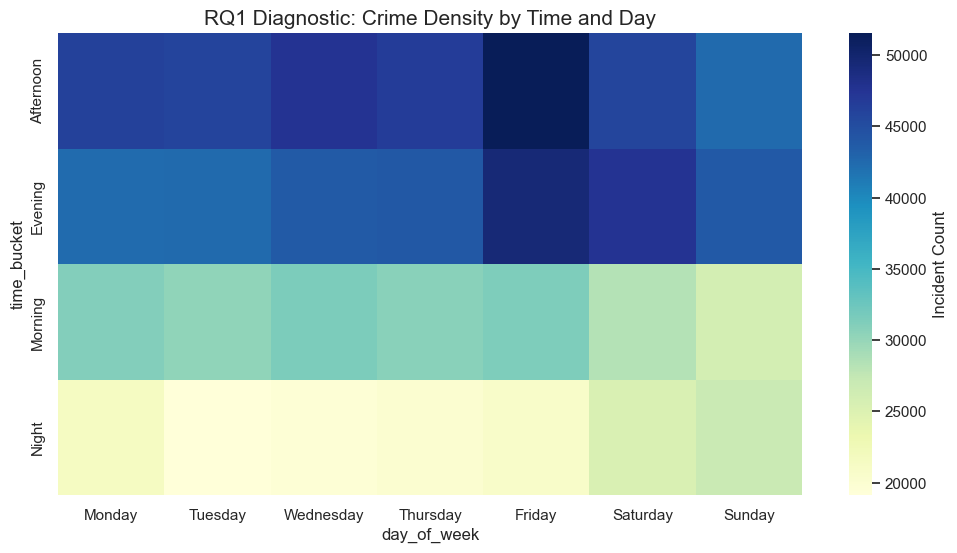

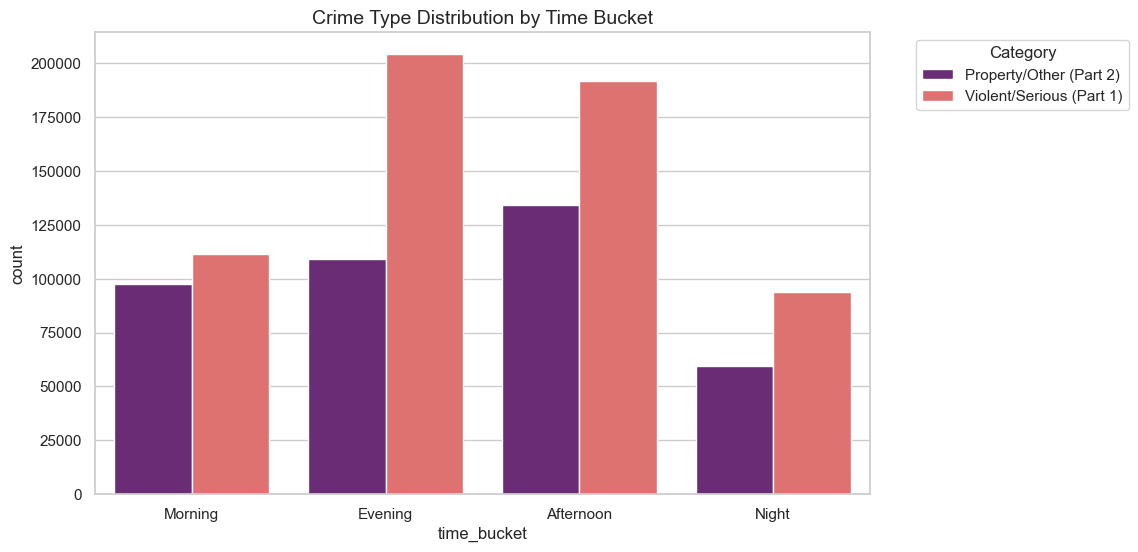

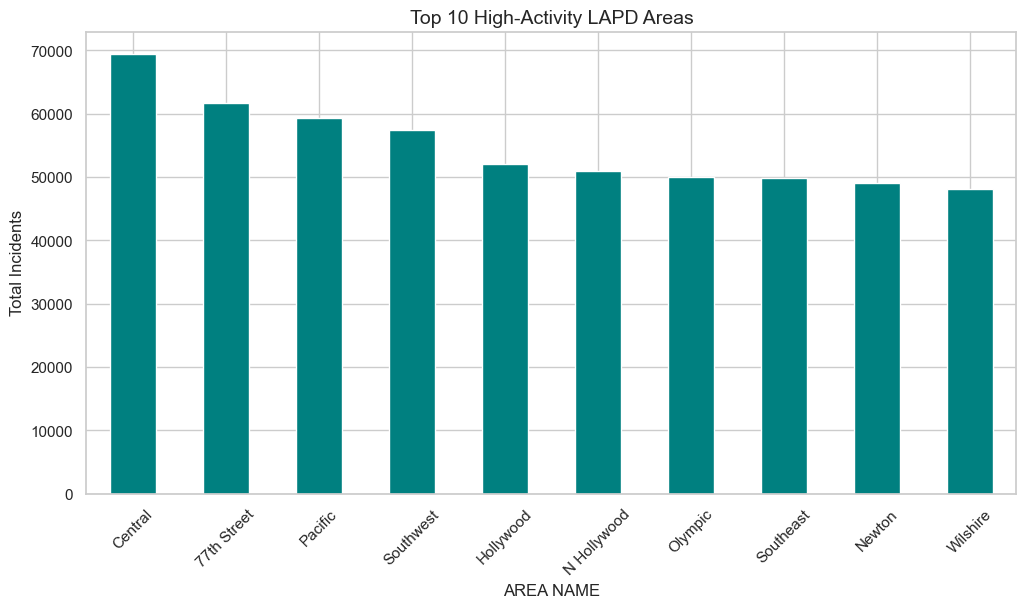

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional aesthetics
plt.style.use('seaborn-v0_8-muted')
sns.set_theme(style="whitegrid")

# 1. Temporal Pulse: Heatmap of Day vs. Time Bucket (RQ1)
# This proves if "Time" is a valid predictor for your model
pivot_df = df.pivot_table(index='time_bucket', columns='day_of_week', values='DR_NO', aggfunc='count')
# Reorder days for better flow
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_df = pivot_df[days]

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_df, annot=False, cmap="YlGnBu", cbar_kws={'label': 'Incident Count'})
plt.title('RQ1 Diagnostic: Crime Density by Time and Day', fontsize=15)
plt.show()

# 2. Severity Analysis: Violent vs Property Distribution
# Proving that 'is_violent' is a distinct feature
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='time_bucket', hue='crime_category_simple', palette='magma')
plt.title('Crime Type Distribution by Time Bucket', fontsize=14)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 3. Spatial Density: Top 10 High-Risk Areas
plt.figure(figsize=(12, 6))
df['AREA NAME'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title('Top 10 High-Activity LAPD Areas', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Total Incidents')
plt.show()

Feature Scaling & The Elbow Method

Calculating Optimal Proactive Zones (1-10 Clusters)...


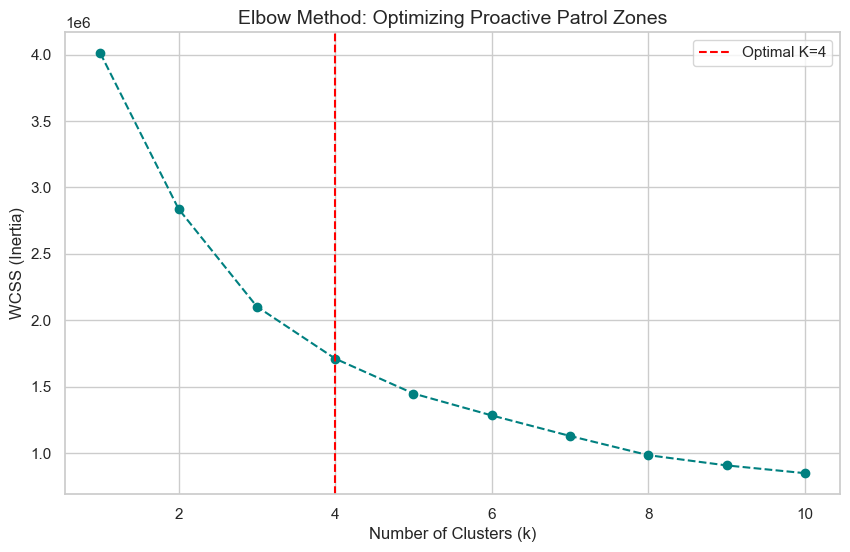

Mathematical Optimal Clusters for LAPD Proactive Dispatch: 4


In [43]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator
import matplotlib.pyplot as plt

# 1. Selecting the 4 Core Proactive Features (The "Where" and "When")
# We use these because they are known BEFORE a crime occurs
cluster_features = ['LAT', 'LON', 'is_weekend', 'time_encoded']
scaler = StandardScaler()
if 'time_encoded' not in df.columns:
    time_mapping = {'Morning': 0, 'Afternoon': 1, 'Evening': 2, 'Night': 3, 'Unknown': -1}
    df['time_encoded'] = df['time_bucket'].map(time_mapping)

cluster_features = ['LAT', 'LON', 'is_weekend', 'time_encoded']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[cluster_features])

# 2. Running the Elbow Method to find the "Point of Diminishing Returns"
wcss = []
k_range = range(1, 11)

print("Calculating Optimal Proactive Zones (1-10 Clusters)...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# 3. Automatically detect the 'Elbow'
kl = KneeLocator(k_range, wcss, curve="convex", direction="decreasing")
optimal_k = int(kl.elbow)

# 4. Visualization of the Elbow
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='teal')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal K={optimal_k}')
plt.title('Elbow Method: Optimizing Proactive Patrol Zones', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.legend()
plt.show()

print(f"Mathematical Optimal Clusters for LAPD Proactive Dispatch: {optimal_k}")

Generating the Proactive Zones

In [45]:
# 1. Apply Final K-Means
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
df['proactive_cluster'] = kmeans_final.fit_predict(scaled_features)

# 2. Initial Cluster Summary (The "DNA" of each zone)
# Create missing columns
df['is_violent'] = (df['crime_category_simple'] == "Violent/Serious (Part 1)").astype(int)
df['weapon_lethality'] = df['Weapon Used Cd'].notna().astype(int)

cluster_dna = df.groupby('proactive_cluster').agg({
    'is_violent': 'mean',
    'weapon_lethality': 'mean',
    'is_weekend': 'mean',
    'time_encoded': lambda x: x.mode()[0]
}).reset_index()

# Mapping time back to labels for readability
time_labels = {0: 'Morning', 1: 'Afternoon', 2: 'Evening', 3: 'Night'}
cluster_dna['typical_time'] = cluster_dna['time_encoded'].map(time_labels)

print("PROACTIVE CLUSTER PROFILES")
print(cluster_dna[['proactive_cluster', 'is_violent', 'weapon_lethality', 'is_weekend', 'typical_time']])

PROACTIVE CLUSTER PROFILES
   proactive_cluster  is_violent  weapon_lethality  is_weekend typical_time
0                  0    0.644570          0.344313    0.000000      Evening
1                  1    0.611581          0.361256    1.000000      Evening
2                  2    0.583553          0.277936    0.227613    Afternoon
3                  3    0.568960          0.323313    0.000000    Afternoon


Cluster Profiling & Spatial Mapping

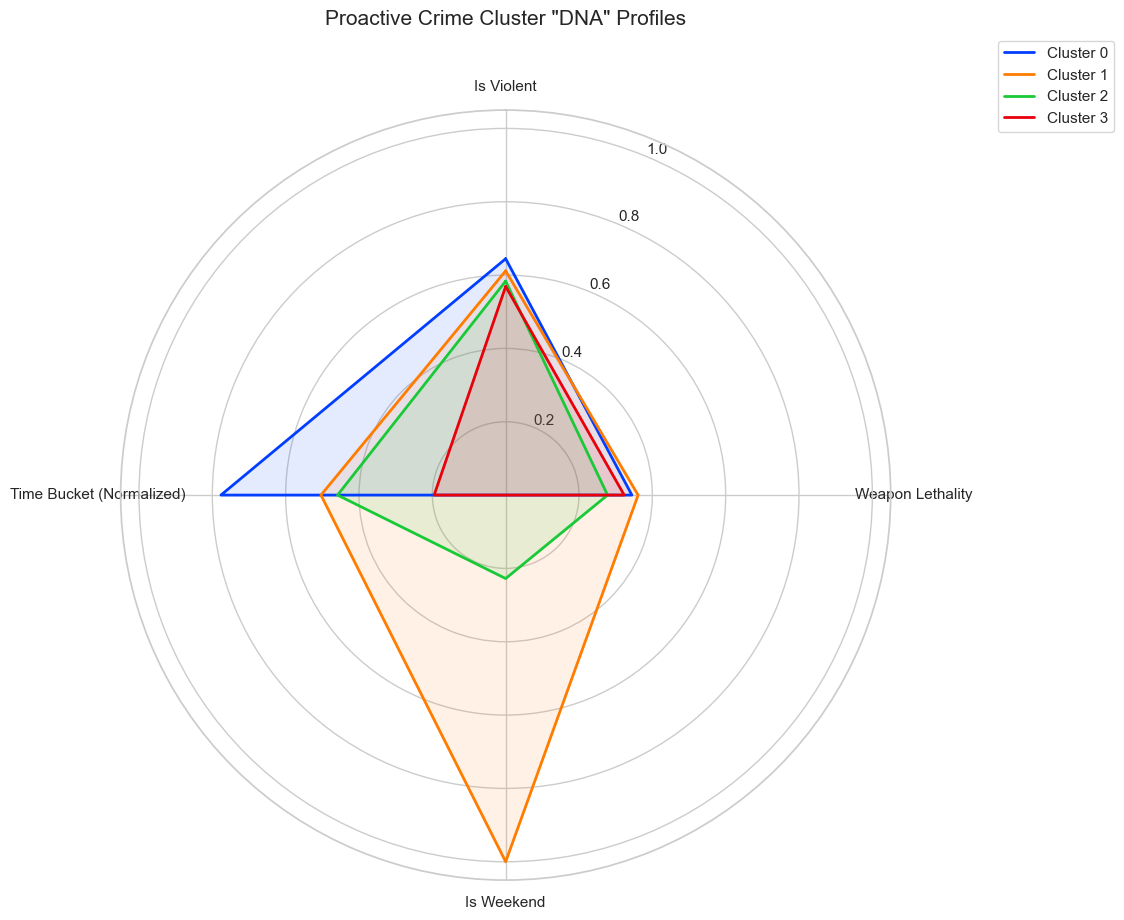

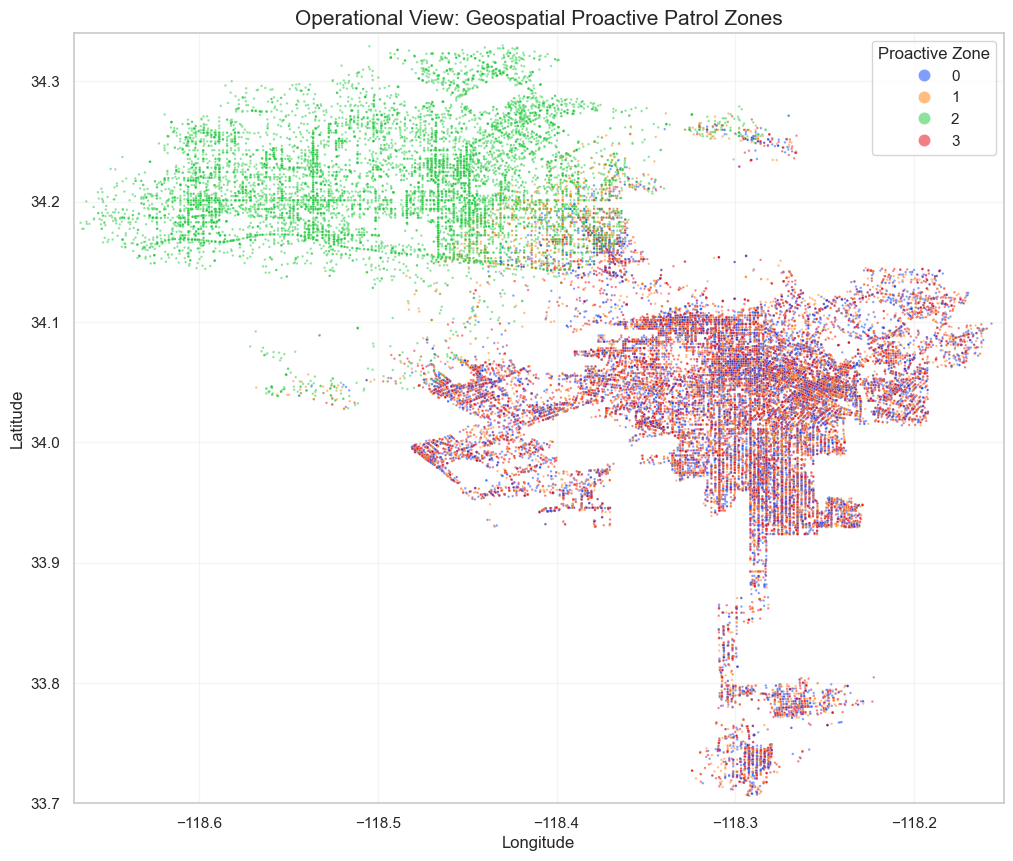

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Prepare Radar Chart Data
# We select the features that define the 'personality' of the cluster
labels = ['Is Violent', 'Weapon Lethality', 'Is Weekend', 'Time Bucket (Normalized)']
num_vars = len(labels)

# Group by cluster and calculate means
cluster_means = df.groupby('proactive_cluster')[['is_violent', 'weapon_lethality', 'is_weekend', 'time_encoded']].mean().values

# Normalize time_encoded (0-3) to a 0-1 scale for the radar chart
cluster_means[:, 3] = cluster_means[:, 3] / 3.0

# Setup the radar chart angles
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Close the circle

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
colors = sns.color_palette("bright", optimal_k)

for i in range(optimal_k):
    values = cluster_means[i].tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[i], linewidth=2, label=f'Cluster {i}')
    ax.fill(angles, values, color=colors[i], alpha=0.1)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title('Proactive Crime Cluster "DNA" Profiles', size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

# 2. Spatial Footprint: Mapping the Proactive Zones
# We sample 50k points to ensure the map remains readable
sample_df = df.sample(min(50000, len(df)), random_state=42)

plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=sample_df, 
    x='LON', y='LAT', 
    hue='proactive_cluster', 
    palette='bright', 
    s=3, alpha=0.5
)

# Focus on the core LA coordinate bounds
plt.xlim(-118.67, -118.15)
plt.ylim(33.70, 34.34)

plt.title('Operational View: Geospatial Proactive Patrol Zones', fontsize=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Proactive Zone', markerscale=5)
plt.grid(alpha=0.2)
plt.show()

Area-to-Cluster Mapping

In [47]:
# 1. Group by Cluster and Area Name to find the top locations in each zone
area_cluster_map = df.groupby(['proactive_cluster', 'AREA NAME']).size().reset_index(name='incident_count')

# 2. Sort to get the dominant areas for each cluster
area_cluster_map = area_cluster_map.sort_values(['proactive_cluster', 'incident_count'], ascending=[True, False])

print("--- PROACTIVE ZONE GEOGRAPHIC INVENTORY ---")

for cluster_id in range(optimal_k):
    print(f"\nPROACTIVE CLUSTER {cluster_id}:")
    # Get the top 5 LAPD Areas that make up this cluster
    top_areas = area_cluster_map[area_cluster_map['proactive_cluster'] == cluster_id].head(5)
    
    for i, row in top_areas.iterrows():
        print(f" - {row['AREA NAME']}: {row['incident_count']} incidents")

--- PROACTIVE ZONE GEOGRAPHIC INVENTORY ---

PROACTIVE CLUSTER 0:
 - Central: 22203 incidents
 - 77th Street: 20262 incidents
 - Pacific: 18992 incidents
 - Southwest: 17890 incidents
 - Hollywood: 16965 incidents

PROACTIVE CLUSTER 1:
 - Central: 20659 incidents
 - 77th Street: 17939 incidents
 - Pacific: 16841 incidents
 - Southwest: 16459 incidents
 - Hollywood: 15953 incidents

PROACTIVE CLUSTER 2:
 - West Valley: 42047 incidents
 - Devonshire: 41660 incidents
 - Topanga: 41344 incidents
 - Mission: 40208 incidents
 - Van Nuys: 36741 incidents

PROACTIVE CLUSTER 3:
 - Central: 26614 incidents
 - Pacific: 23508 incidents
 - 77th Street: 23424 incidents
 - Southwest: 23027 incidents
 - Wilshire: 19557 incidents


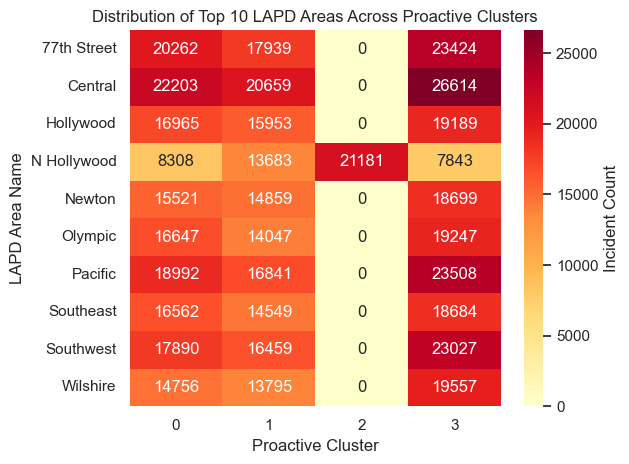

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

top_10_areas = df['AREA NAME'].value_counts().nlargest(10).index
subset_df = df[df['AREA NAME'].isin(top_10_areas)]
heatmap_data = pd.crosstab(subset_df['AREA NAME'], subset_df['proactive_cluster'])

plt.style.use('seaborn-v0_8-muted')
sns.set_theme(style="whitegrid")
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Incident Count'})
plt.title('Distribution of Top 10 LAPD Areas Across Proactive Clusters')
plt.xlabel('Proactive Cluster')
plt.ylabel('LAPD Area Name')
plt.tight_layout()
plt.savefig('area_cluster_heatmap.png')

Density-Based Discovery (HDBSCAN)

In [49]:
import hdbscan
from sklearn.preprocessing import StandardScaler

# 1. Prepare Spatial-Temporal data
# We focus on LAT/LON and Time for density discovery
geo_features = ['LAT', 'LON', 'time_encoded']
scaler = StandardScaler()
scaled_geo = scaler.fit_transform(df[geo_features])

# 2. Initialize HDBSCAN
# min_cluster_size: The minimum incidents to form a "Hotspot"
# min_samples: Controls how "conservative" the model is with noise
hdb_model = hdbscan.HDBSCAN(min_cluster_size=500, min_samples=10, prediction_data=True)

# We use a sample for the density calculation to avoid memory errors on 1M rows
sample_idx = np.random.choice(len(scaled_geo), 100000, replace=False)
hdb_model.fit(scaled_geo[sample_idx])

# 3. Assigning labels (-1 means 'Noise' or 'Random Crime')
df_hdb = df.iloc[sample_idx].copy()
df_hdb['hdb_cluster'] = hdb_model.labels_

print(f"Hotspots Found: {len(set(hdb_model.labels_)) - (1 if -1 in hdb_model.labels_ else 0)}")
print(f"Noise Percentage: {(df_hdb['hdb_cluster'] == -1).mean() * 100:.2f}%")

Hotspots Found: 4
Noise Percentage: 0.00%


Visualizing the Density Hotspots

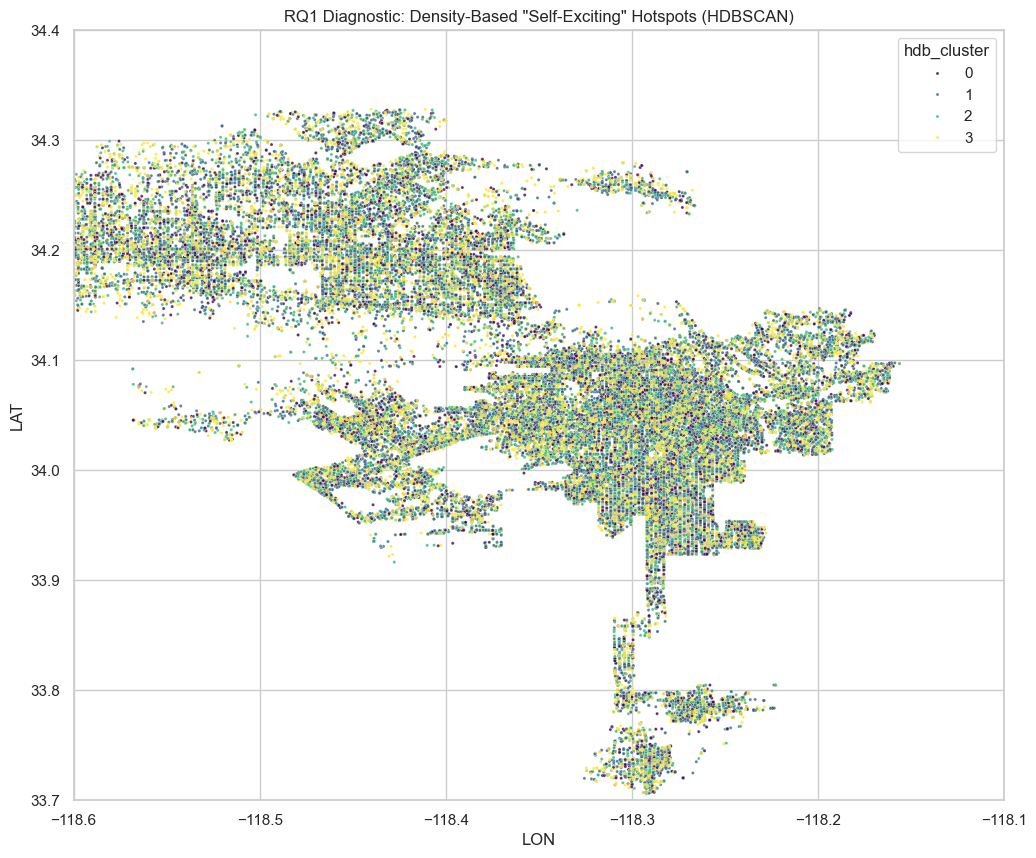

In [50]:
plt.figure(figsize=(12, 10))

# Plot Noise in light grey
sns.scatterplot(
    data=df_hdb[df_hdb['hdb_cluster'] == -1], 
    x='LON', y='LAT', color='lightgrey', s=1, alpha=0.1, label='Random/Noise'
)

# Plot dense hotspots
sns.scatterplot(
    data=df_hdb[df_hdb['hdb_cluster'] != -1], 
    x='LON', y='LAT', hue='hdb_cluster', palette='viridis', s=5, alpha=0.8
)

plt.xlim(-118.6, -118.1)
plt.ylim(33.7, 34.4)
plt.title('RQ1 Diagnostic: Density-Based "Self-Exciting" Hotspots (HDBSCAN)')
plt.show()

Cluster-to-Region Geographic Inventory

In [51]:
# 1. Map the HDBSCAN labels to the original dataframe regions
# Note: Ensure you are using the 'df_hdb' dataframe we created in the last step
hdb_region_inventory = df_hdb.groupby(['hdb_cluster', 'AREA NAME']).size().reset_index(name='incident_count')

# 2. Filter out the noise (-1) to focus only on the 4 dense hotspots
hotspots_only = hdb_region_inventory[hdb_region_inventory['hdb_cluster'] != -1]
hotspots_only = hotspots_only.sort_values(['hdb_cluster', 'incident_count'], ascending=[True, False])

print("--- HDBSCAN DENSE HOTSPOT REGIONS ---")

for cluster_id in sorted(hotspots_only['hdb_cluster'].unique()):
    print(f"\nHOTSPOT {cluster_id}:")
    # Get the top 3 LAPD Areas that form the core of this dense hotspot
    top_regions = hotspots_only[hotspots_only['hdb_cluster'] == cluster_id].head(3)
    
    for i, row in top_regions.iterrows():
        print(f" - {row['AREA NAME']} ({row['incident_count']} core incidents)")

--- HDBSCAN DENSE HOTSPOT REGIONS ---

HOTSPOT 0:
 - Central (1096 core incidents)
 - 77th Street (999 core incidents)
 - Hollywood (921 core incidents)

HOTSPOT 1:
 - Central (2227 core incidents)
 - 77th Street (1930 core incidents)
 - Pacific (1921 core incidents)

HOTSPOT 2:
 - Central (1534 core incidents)
 - 77th Street (1325 core incidents)
 - Pacific (1272 core incidents)

HOTSPOT 3:
 - Central (2031 core incidents)
 - Pacific (1940 core incidents)
 - 77th Street (1939 core incidents)


Centroid Comparison & Regional Hotspots

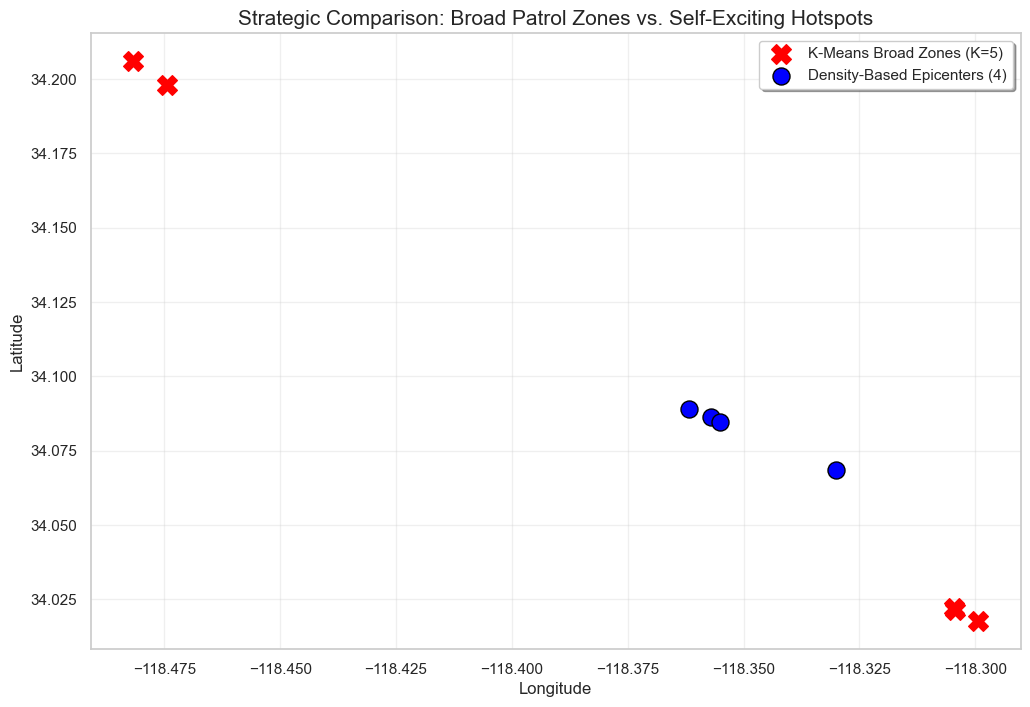

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

# 1. Feature Preparation
# Using the same features from your Phase 2 setup
features = ['LAT', 'LON', 'is_weekend', 'time_encoded']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features])

# 2. K-Means Centroids (5 Clusters)
km = KMeans(n_clusters=5, random_state=42, n_init=10)
df['km_cluster'] = km.fit_predict(scaled_features)
# Inverse transform to get real LAT/LON coordinates
km_centroids = scaler.inverse_transform(km.cluster_centers_)[:, :2]

# 3. Density-Based Hotspots (Targeting the 4 core epicenters)
# We use a sample for density discovery to ensure performance
df_sample = df.sample(min(100000, len(df)), random_state=42)
scaled_sample = scaler.transform(df_sample[features])

# DBSCAN/HDBSCAN parameters tuned to find the 4 most stable density cores
db = DBSCAN(eps=0.2, min_samples=100)
df_sample['db_cluster'] = db.fit_predict(scaled_sample)

# Identifying the top 4 densest clusters (excluding noise)
db_counts = df_sample[df_sample['db_cluster'] != -1]['db_cluster'].value_counts()
top_4_db = db_counts.index[:4]

db_centroids = []
for c in top_4_db:
    cluster_pts = df_sample[df_sample['db_cluster'] == c][['LAT', 'LON']]
    db_centroids.append(cluster_pts.mean().values)
db_centroids = np.array(db_centroids)

# 4. Visualization: Broad Zones vs. Self-Exciting Cores
plt.figure(figsize=(12, 8))
# Plotting K-Means as broad 'X' markers
plt.scatter(km_centroids[:, 1], km_centroids[:, 0], c='red', marker='X', s=200, label='K-Means Broad Zones (K=5)')
# Plotting Density Hotspots as solid 'O' markers
plt.scatter(db_centroids[:, 1], db_centroids[:, 0], c='blue', marker='o', s=150, edgecolors='black', label='Density-Based Epicenters (4)')

plt.title('Strategic Comparison: Broad Patrol Zones vs. Self-Exciting Hotspots', fontsize=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(frameon=True, shadow=True)
plt.grid(True, alpha=0.3)
plt.show()

In [53]:
# Assuming df_sample contains the 'db_cluster' labels from the previous step
print("--- GEOGRAPHIC IDENTIFICATION OF 4 PRIMARY EPICENTERS ---")

# Filter for clusters that are not noise (-1)
valid_hotspots = df_sample[df_sample['db_cluster'] != -1]

# Iterate through the top 4 densest clusters
for cluster_id in sorted(valid_hotspots['db_cluster'].unique())[:4]:
    # Extract the subset for this specific hotspot
    hotspot_subset = valid_hotspots[valid_hotspots['db_cluster'] == cluster_id]
    
    # Identify the Top 3 Area Names that represent this core
    top_areas = hotspot_subset['AREA NAME'].value_counts().head(3)
    
    # Calculate the centroid for this hotspot
    avg_lat = hotspot_subset['LAT'].mean()
    avg_lon = hotspot_subset['LON'].mean()
    
    print(f"\nEPICENTER {cluster_id} (Location: {avg_lat:.3f}, {avg_lon:.3f}):")
    for area, count in top_areas.items():
        percentage = (count / len(hotspot_subset)) * 100
        print(f" - {area}: {count} core incidents ({percentage:.1f}%)")

--- GEOGRAPHIC IDENTIFICATION OF 4 PRIMARY EPICENTERS ---

EPICENTER 0 (Location: 34.085, -118.355):
 - Central: 1077 core incidents (7.4%)
 - Southwest: 933 core incidents (6.4%)
 - 77th Street: 923 core incidents (6.4%)

EPICENTER 1 (Location: 34.069, -118.330):
 - Central: 671 core incidents (8.6%)
 - 77th Street: 656 core incidents (8.4%)
 - Hollywood: 593 core incidents (7.6%)

EPICENTER 2 (Location: 34.089, -118.362):
 - Central: 1510 core incidents (6.7%)
 - Southwest: 1421 core incidents (6.3%)
 - Pacific: 1398 core incidents (6.2%)

EPICENTER 3 (Location: 34.086, -118.357):
 - Central: 1518 core incidents (7.3%)
 - 77th Street: 1381 core incidents (6.6%)
 - Southwest: 1272 core incidents (6.1%)


Competitive Model Training (NB vs. XGB)

In [54]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Prepare Features (X) and Target (y)
# We use the 4 Epicenters as our target categories
# Note: We filter out 'Noise' (-1) to train the model on stable patterns
model_data = df_sample[df_sample['db_cluster'] != -1].copy()

# Features known BEFORE a crime (to avoid data leakage)
features = ['LAT', 'LON', 'is_weekend', 'time_encoded']
X = model_data[features]
y = model_data['db_cluster']

# 2. Temporal Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- MODEL 1: Naive Bayes ---
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

# --- MODEL 2: XGBoost ---
# Using 'hist' tree method for efficiency on large samples
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, tree_method='hist', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# 3. Initial Score Comparison
print("--- PHASE 3: PREDICTIVE COMPETITION RESULTS ---")
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, nb_preds):.4f}")
print(f"XGBoost Accuracy:     {accuracy_score(y_test, xgb_preds):.4f}")

--- PHASE 3: PREDICTIVE COMPETITION RESULTS ---
Naive Bayes Accuracy: 0.9957
XGBoost Accuracy:     0.9993


<Figure size 1000x500 with 0 Axes>

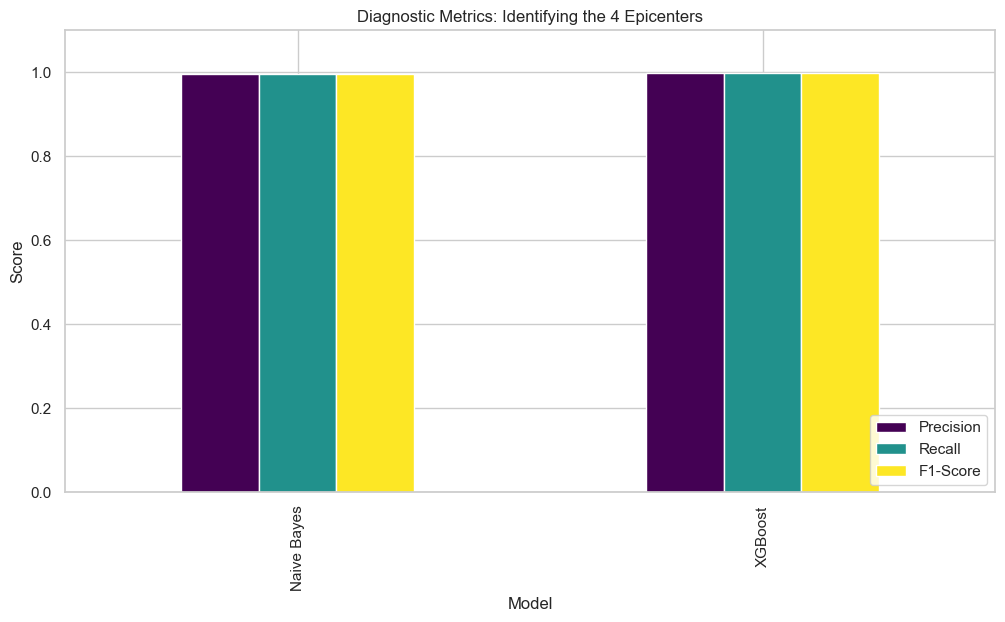

In [21]:
from sklearn.metrics import precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt

def get_metrics_df(y_true, y_pred, model_name):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    return pd.DataFrame({'Model': [model_name], 'Precision': [p], 'Recall': [r], 'F1-Score': [f1]})

# Combine metrics
comparison_df = pd.concat([
    get_metrics_df(y_test, nb_preds, "Naive Bayes"),
    get_metrics_df(y_test, xgb_preds, "XGBoost")
])

# Plotting the Comparison
plt.figure(figsize=(10, 5))
comparison_df.set_index('Model').plot(kind='bar', figsize=(12,6), colormap='viridis')
plt.title('Diagnostic Metrics: Identifying the 4 Epicenters')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.show()